STEP 1: Data Aggregation

scraping treatment data from EIA API

In [1]:
import numpy as np
import requests
import pandas as pd
from bs4 import BeautifulSoup
import io

In [2]:
# extract list of state codes from EIA website
url = "https://www.eia.gov/dnav/pet/pet_pri_dfp1_k_m.htm"
page = requests.get(url)
soup = BeautifulSoup(page.text, "html.parser")

exclude_codes = ["F009960", "F001236", "F003075", "F005071", "F005061", "F005074"]

codes = []
for link in soup.find_all("a"):
    href = link.get("href", "")
    text = link.text.strip()
    if "s=F" in href and "&f=M" in href:
        code = href.split("s=")[-1].split("&")[0]
        num_part = int(code[1:7])
        if num_part % 1000 == 0:
          continue
        if code[:7] in exclude_codes:
          continue
        codes.append(code)
print(codes)

['F001242__3', 'F001354__3', 'F002017__3', 'F002018__3', 'F002020__3', 'F002021__3', 'F002026__3', 'F002031__3', 'F002038__3', 'F002039__3', 'F002040__3', 'F002046__3', 'F003001__3', 'F003005__3', 'F003022__3', 'F003028__3', 'F003035__3', 'F003048__3', 'F004008__3', 'F004030__3', 'F004049__3', 'F004056__3', 'F005006__3']


In [3]:
all_data = []
API_URL = "https://api.eia.gov/v2/petroleum/pri/dfp1/data/"

# call the EIA API
for code in codes:
    params = {
        "api_key": "vUc8dcxSykilX0CpePaERE6F0NRipDBTqiB1Jl51",
        "frequency": "monthly",
        "data[0]": "value",
        "facets[series][]": code,
        "sort[0][column]": "period",
        "sort[0][direction]": "desc",
        "offset": 0,
        "length": 5000
    }
    try:
      response = requests.get(API_URL, params=params)
      response.raise_for_status()
      data = response.json()

      # Extract records
      for r in data['response']['data']:
          all_data.append({
              "State_Code": code,
              "Period": r['period'],
              "Price": r['value']
          })
    except Exception as e:
      print(f"Error fetching data for code {code}: {e}")

# Convert to DataFrame and process as before
df = pd.DataFrame(all_data)
df['Period'] = pd.to_datetime(df['Period'])
df['Year'] = df['Period'].dt.year
df['Month'] = df['Period'].dt.month
df = df[(df['Year'] >= 1978) & (df['Year'] <= 2024)]
df.sort_values(by=['State_Code', 'Year', 'Month'], inplace=True)

df.head(10)

,State_Code,Period,Price,Year,Month
572,F001242__3,1978-01-01,14.71,1978,1
571,F001242__3,1978-02-01,14.8,1978,2
570,F001242__3,1978-03-01,14.74,1978,3
569,F001242__3,1978-04-01,14.67,1978,4
568,F001242__3,1978-05-01,14.71,1978,5
567,F001242__3,1978-06-01,14.72,1978,6
566,F001242__3,1978-07-01,14.75,1978,7
565,F001242__3,1978-08-01,14.65,1978,8
564,F001242__3,1978-09-01,14.7,1978,9
563,F001242__3,1978-10-01,14.78,1978,10


In [4]:
# data cleaning: remove rows where price is withdrawn
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price'])
df = df.reset_index(drop=True)

In [5]:
# add state column
state_mapping = {
    'F001242__3': 'PA',
    'F001354__3': 'WV',
    'F002017__3': 'IL',
    'F002018__3': 'IN',
    'F002020__3': 'KS',
    'F002021__3': 'KY',
    'F002026__3': 'MI',
    'F002031__3': 'NE',
    'F002038__3': 'ND',
    'F002039__3': 'OH',
    'F002040__3': 'OK',
    'F002046__3': 'SD',
    'F003001__3': 'AL',
    'F003005__3': 'AR',
    'F003022__3': 'LA',
    'F003028__3': 'MS',
    'F003035__3': 'NM',
    'F003048__3': 'TX',
    'F004008__3': 'CO',
    'F004030__3': 'MT',
    'F004049__3': 'UT',
    'F004056__3': 'WY',
    'F005006__3': 'CA'
}

# get state mappings
df['state'] = df['State_Code'].map(state_mapping)
print(df.head(10))
print(df.shape)

   State_Code     Period  Price  Year  Month state
0  F001242__3 1978-01-01  14.71  1978      1    PA
1  F001242__3 1978-02-01  14.80  1978      2    PA
2  F001242__3 1978-03-01  14.74  1978      3    PA
3  F001242__3 1978-04-01  14.67  1978      4    PA
4  F001242__3 1978-05-01  14.71  1978      5    PA
5  F001242__3 1978-06-01  14.72  1978      6    PA
6  F001242__3 1978-07-01  14.75  1978      7    PA
7  F001242__3 1978-08-01  14.65  1978      8    PA
8  F001242__3 1978-09-01  14.70  1978      9    PA
9  F001242__3 1978-10-01  14.78  1978     10    PA
(12784, 6)


Join outcome variable data from external data source: https://www.eia.gov/electricity/data/state/

In [6]:
cons_csv = pd.read_csv('data/consumption_data.csv')
cons_csv.head(20)

,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE (UNITS),CONSUMPTION
0,2001,1,AK,Total Electric Power Industry,Coal (Short Tons),"47,615"
1,2001,1,AK,Total Electric Power Industry,Petroleum (Barrels),"124,998"
2,2001,1,AK,Total Electric Power Industry,Natural Gas (Mcf),"3,941,267"
3,2001,1,AK,"Electric Generators, Electric Utilities",Coal (Short Tons),"16,535"
4,2001,1,AK,"Electric Generators, Electric Utilities",Petroleum (Barrels),"114,198"
5,2001,1,AK,"Electric Generators, Electric Utilities",Natural Gas (Mcf),"3,189,447"
6,2001,1,AK,"Combined Heat and Power, Electric Power",Coal (Short Tons),"22,890"
7,2001,1,AK,"Combined Heat and Power, Electric Power",Petroleum (Barrels),550
8,2001,1,AK,"Combined Heat and Power, Commercial Power",Coal (Short Tons),"8,190"
9,2001,1,AK,"Combined Heat and Power, Commercial Power",Petroleum (Barrels),"1,590"


In [7]:
# filter for only petroleum derived electricity consumption
cons_csv = cons_csv[(cons_csv['ENERGY SOURCE              (UNITS)'].str.contains('Petroleum')) & (cons_csv['TYPE OF PRODUCER']=='Total Electric Power Industry')]
print(cons_csv.head())
print(cons_csv.shape)

    YEAR MONTH STATE               TYPE OF PRODUCER  \
1   2001     1    AK  Total Electric Power Industry   
13  2001     1    AL  Total Electric Power Industry   
29  2001     1    AR  Total Electric Power Industry   
39  2001     1    AZ  Total Electric Power Industry   
51  2001     1    CA  Total Electric Power Industry   

   ENERGY SOURCE              (UNITS) CONSUMPTION  
1                 Petroleum (Barrels)     124,998  
13                Petroleum (Barrels)     284,241  
29                Petroleum (Barrels)     209,194  
39                Petroleum (Barrels)     268,016  
51                Petroleum (Barrels)     960,824  
(15392, 6)


In [8]:
# join the two tables
cons_csv['YEAR'] = cons_csv['YEAR'].astype('int32')
cons_csv['MONTH'] = cons_csv['MONTH'].astype('int32')
df = df.merge(cons_csv, left_on=['Year', 'state', 'Month'], right_on=['YEAR', 'STATE', 'MONTH'], how='inner')
df = df.drop(columns=['YEAR', 'STATE', 'MONTH'])
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  
0   1,005,652  
1     196,117  
2     478,840  
3     960,097  
4     524,322  
(6499, 9)


Join confounder yield curve data from external source: https://fred.stlouisfed.org/series/T10Y2Y

In [9]:
yield_curve = pd.read_csv('data/treasury_data.csv')
yield_curve.head()

,observation_date,T10Y2Y
0,1976-06-01,0.68
1,1976-06-02,0.71
2,1976-06-03,0.70
3,1976-06-04,0.77
4,1976-06-07,0.79


In [10]:
# join with existing df
yield_curve.rename(columns={'T10Y2YM':'Treasury Yield Spread (10Y-2Y)'}, inplace=True)
yield_curve['Year'] = yield_curve['observation_date'].str.split('-').str[0]
yield_curve['Month'] = yield_curve['observation_date'].str.split('-').str[1]
yield_curve.drop(columns=['observation_date'], inplace=True)
yield_curve['Year'] = yield_curve['Year'].astype('int32')
yield_curve['Month'] = yield_curve['Month'].astype('int32')
yield_curve.drop_duplicates(subset=['Year', 'Month'], keep='first', inplace=True)

df = df.merge(yield_curve, on=['Year','Month'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  
0   1,005,652     NaN  
1     196,117    0.55  
2     478,840    0.46  
3     960,097    0.76  
4     524,322    1.07  
(6499, 10)


Join confounder inflation rate data from external source: https://fred.stlouisfed.org/series/FPCPITOTLZGUSA

In [11]:
inflation = pd.read_csv('data/inflation_data.csv')
inflation.head()

,observation_date,FPCPITOTLZGUSA
0,1960-01-01,1.457976
1,1961-01-01,1.070724
2,1962-01-01,1.198773
3,1963-01-01,1.239669
4,1964-01-01,1.278912


In [12]:
# join with existing df
inflation.rename(columns={'FPCPITOTLZGUSA':'Inflation Rate (%)'}, inplace=True)
inflation['Year'] = inflation['observation_date'].str.split('-').str[0]
inflation.drop(columns=['observation_date'], inplace=True)
inflation['Year'] = inflation['Year'].astype('int32')

df = df.merge(inflation, on='Year', how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  
0   1,005,652     NaN            2.826171  
1     196,117    0.55            2.826171  
2     478,840    0.46            2.826171  
3     960,097    0.76            2.826171  
4     524,322    1.07       

Join confounder industrial production index data from external source: https://fred.stlouisfed.org/series/INDPRO

In [13]:
ind_idx = pd.read_csv('data/industrial_production_data.csv')
ind_idx.head()

,observation_date,INDPRO
0,1919-01-01,4.8739
1,1919-02-01,4.6585
2,1919-03-01,4.5238
3,1919-04-01,4.6046
4,1919-05-01,4.6315


In [14]:
# join with existing df
ind_idx.rename(columns={'INDPRO':'Industrial Production Index'}, inplace=True)
ind_idx['Year'] = ind_idx['observation_date'].str.split('-').str[0]
ind_idx['Month'] = ind_idx['observation_date'].str.split('-').str[1]
ind_idx.drop(columns=['observation_date'], inplace=True)
ind_idx['Year'] = ind_idx['Year'].astype('int32')
ind_idx['Month'] = ind_idx['Month'].astype('int32')

df = df.merge(ind_idx, on=['Year', 'Month'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  Industrial Production Index  
0   1,005,652     NaN            2.826171                      91.9020  
1     196,117    0.55            2.826171                      91.3034  
2     478,840    0.46        

Join confounder weather data by calling NOAA API

In [15]:
# integrate temperature on monthly state-level basis
import time

# call NOAA endpoint to extract weather data
noaa_url = "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/{state}/tavg/1/0/2000-2025.json"
all_data = []

for state_id in range(1, 51):
    url = noaa_url.format(state=state_id)
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        j = r.json()
        for date, value in j["data"].items():
            year = int(date[:4])
            month = int(date[4:])
            all_data.append({
                "state_id": state_id,
                "year": year,
                "month": month,
                "temperature": value
            })

    except Exception as e:
        print(f"State {state_id} failed: {e}")

    time.sleep(0.4)

tmp = pd.DataFrame(all_data)
print(tmp.head())
print(tmp.shape)

State 49 failed: 404 Client Error: Not Found for url: https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/49/tavg/1/0/2000-2025.json
   state_id  year  month      temperature
0         1  2000      1  {'value': 46.5}
1         1  2000      2  {'value': 52.3}
2         1  2000      3  {'value': 58.9}
3         1  2000      4  {'value': 60.1}
4         1  2000      5    {'value': 74}
(15239, 4)


In [16]:
def extract_temp(val):
  return val['value']

tmp['temperature'] = tmp['temperature'].apply(extract_temp)

state_id_to_code = {
    1: "AL", 2: "AZ", 3: "AR", 4: "CA", 5: "CO",
    6: "CT", 7: "DE", 8: "FL", 9: "GA", 10: "HI",
    11: "ID", 12: "IL", 13: "IN", 14: "IA", 15: "KS",
    16: "KY", 17: "LA", 18: "ME", 19: "MD", 20: "MA",
    21: "MI", 22: "MN", 23: "MS", 24: "MO", 25: "MT",
    26: "NE", 27: "NV", 28: "NH", 29: "NJ", 30: "NM",
    31: "NY", 32: "NC", 33: "ND", 34: "OH", 35: "OK",
    36: "OR", 37: "PA", 38: "RI", 39: "SC", 40: "SD",
    41: "TN", 42: "TX", 43: "UT", 44: "VT", 45: "VA",
    46: "WA", 47: "WV", 48: "WI", 49: "WY", 50: "AK"
}

# map code to existing state abbrev
tmp['State'] = tmp['state_id'].map(state_id_to_code)
tmp.drop(columns=['state_id'], inplace=True)
tmp.head()

,year,month,temperature,State
0,2000,1,46.5,AL
1,2000,2,52.3,AL
2,2000,3,58.9,AL
3,2000,4,60.1,AL
4,2000,5,74.0,AL


In [17]:
# merge with existing df
tmp.rename(columns={'temperature':'temperature (F)','year':'Year','month':'Month','State':'state'}, inplace=True)
tmp['Year'] = tmp['Year'].astype('int32')
tmp['Month'] = tmp['Month'].astype('int32')
df = df.merge(tmp, on=['state', 'Year', 'Month'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  Industrial Production Index  \
0   1,005,652     NaN            2.826171                      91.9020   
1     196,117    0.55            2.826171                      91.3034   
2     478,840    0.46     

Join confounder electricity price data from external source: https://www.eia.gov/state/seds/seds-data-complete.php

In [18]:
prices = pd.read_csv('data/electricity_price_data.csv')
prices.head()

,State,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AK,1.39,1.46,1.55,1.68,2.46,2.69,2.93,3.07,3.08,...,24.86,18.96,16.88,18.87,22.10,21.26,17.16,20.03,27.33,23.84
1,AL,1.37,1.51,1.61,1.84,2.50,2.83,3.21,3.76,3.99,...,18.63,15.70,14.86,15.97,16.69,16.38,14.84,17.85,23.37,21.11
2,AR,1.51,1.65,1.69,1.81,2.49,2.96,3.29,3.81,4.00,...,18.86,15.86,14.62,15.76,16.45,16.06,14.79,18.42,23.84,21.76
3,AZ,1.97,2.06,2.14,2.34,3.12,3.87,4.12,4.59,5.08,...,25.52,21.91,20.13,21.80,23.99,23.31,21.26,25.07,31.72,30.28
4,CA,1.74,1.81,1.91,2.13,3.03,3.47,3.80,4.27,4.58,...,25.65,22.16,20.17,21.99,24.47,24.69,23.66,28.44,37.35,35.72


In [19]:
# remove empty columns
remove_colums = []
for col in prices.columns:
  if 'Unnamed' in col:
    remove_colums.append(col)

prices.drop(columns=remove_colums, inplace=True)

prices = prices.melt(
    id_vars=["State"],        # Columns to keep
    var_name="Year",          # Name for the new "variable" column
    value_name="Price"        # Name for the new "value" column
)

# Convert Year and Price to numeric
prices["Year"] = prices["Year"].astype(int)
prices["Price"] = pd.to_numeric(prices["Price"], errors='coerce')

print(prices.head())

  State  Year  Price
0    AK  1970   1.39
1    AL  1970   1.37
2    AR  1970   1.51
3    AZ  1970   1.97
4    CA  1970   1.74


In [20]:
# join with existing df
prices.rename(columns={'Price':'Electricity Price ($ per million BTU)','State':'state'}, inplace=True)
prices['Year'] = prices['Year'].astype('int32')
df = df.merge(prices, on=['state', 'Year'], how='inner')
print(df.head())
print(df.shape)

   State_Code     Period  Price  Year  Month state  \
0  F001242__3 2001-01-01  28.02  2001      1    PA   
1  F001242__3 2001-02-01  28.52  2001      2    PA   
2  F001242__3 2001-03-01  26.20  2001      3    PA   
3  F001242__3 2001-04-01  26.31  2001      4    PA   
4  F001242__3 2001-05-01  27.43  2001      5    PA   

                TYPE OF PRODUCER ENERGY SOURCE              (UNITS)  \
0  Total Electric Power Industry                Petroleum (Barrels)   
1  Total Electric Power Industry                Petroleum (Barrels)   
2  Total Electric Power Industry                Petroleum (Barrels)   
3  Total Electric Power Industry                Petroleum (Barrels)   
4  Total Electric Power Industry                Petroleum (Barrels)   

  CONSUMPTION  T10Y2Y  Inflation Rate (%)  Industrial Production Index  \
0   1,005,652     NaN            2.826171                      91.9020   
1     196,117    0.55            2.826171                      91.3034   
2     478,840    0.46     

In [21]:
opec = pd.read_csv('data/OPEC_data.csv')
opec.head()

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"3,124","3,055","3,456","3,706","3,767","4,121","4,256","4,493","4,714","4,583",...,"8,068","8,356","8,541","8,726","8,445","7,113","7,904","8,375","8,607","9,052"


In [22]:
# extract years as distinct rows
opec = pd.melt(opec, var_name='Year', value_name='OPEC supply (1000 b/d)')
opec.head()

,Year,OPEC supply (1000 b/d)
0,1980,"3,124"
1,1981,"3,055"
2,1982,"3,456"
3,1983,"3,706"
4,1984,"3,767"


In [23]:
opec['Year'] = opec['Year'].astype(int)
df = df.merge(opec, on='Year')
df.head()

,State_Code,Period,Price,Year,Month,state,TYPE OF PRODUCER,ENERGY SOURCE (UNITS),CONSUMPTION,T10Y2Y,Inflation Rate (%),Industrial Production Index,temperature (F),Electricity Price ($ per million BTU),OPEC supply (1000 b/d)
0,F001242__3,2001-01-01,28.02,2001,1,PA,Total Electric Power Industry,Petroleum (Barrels),"1,005,652",NaN,2.826171,91.9020,28.0,11.26,"6,111"
1,F001242__3,2001-02-01,28.52,2001,2,PA,Total Electric Power Industry,Petroleum (Barrels),"196,117",0.55,2.826171,91.3034,30.9,11.26,"6,111"
2,F001242__3,2001-03-01,26.20,2001,3,PA,Total Electric Power Industry,Petroleum (Barrels),"478,840",0.46,2.826171,91.1162,35.3,11.26,"6,111"
3,F001242__3,2001-04-01,26.31,2001,4,PA,Total Electric Power Industry,Petroleum (Barrels),"960,097",0.76,2.826171,90.7891,47.5,11.26,"6,111"
4,F001242__3,2001-05-01,27.43,2001,5,PA,Total Electric Power Industry,Petroleum (Barrels),"524,322",1.07,2.826171,90.3555,58.9,11.26,"6,111"


In [24]:
# save aggregated data
df.to_csv('data/data102_oil_data_final.csv')

STEP 2: generate visualizations for EDA section

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# data cleaning: changing colum dtypes
df['CONSUMPTION'] = pd.to_numeric(
    df['CONSUMPTION'].astype(str).str.replace(',', ''),
    errors='coerce'
).astype(pd.Int64Dtype())
df['OPEC supply (1000 b/d)'] = pd.to_numeric(
    df['OPEC supply (1000 b/d)'].astype(str).str.replace(',', ''),
    errors='coerce'
).astype(pd.Int64Dtype())

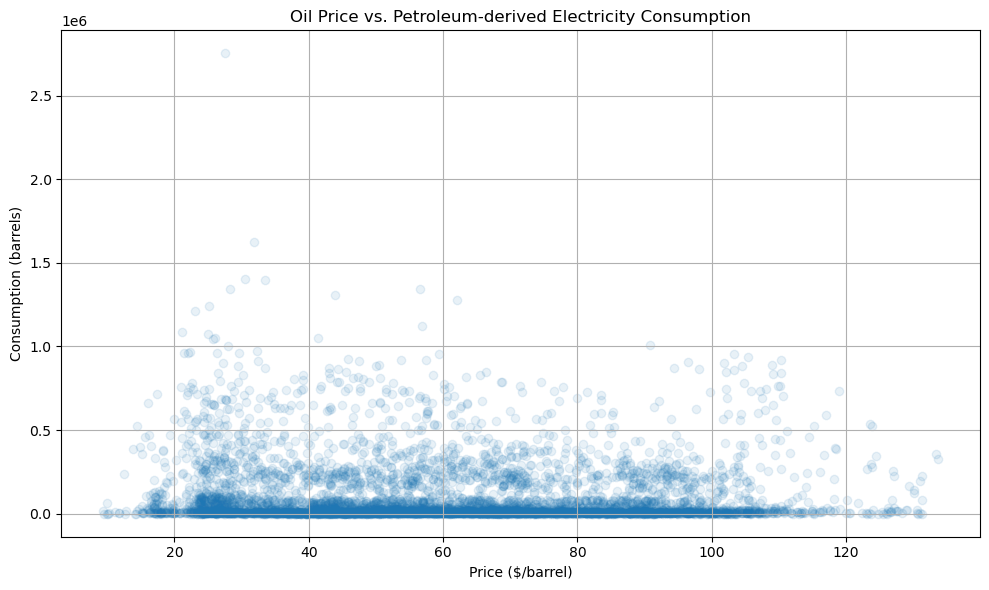

In [27]:
# visualize treatment vs outcome
plt.figure(figsize=(10, 6))
plt.scatter(df['Price'], df['CONSUMPTION'], alpha=0.1)
plt.xlabel('Price ($/barrel)')
plt.ylabel('Consumption (barrels)')
plt.title('Oil Price vs. Petroleum-derived Electricity Consumption')
plt.grid(True)
plt.tight_layout()
plt.show()

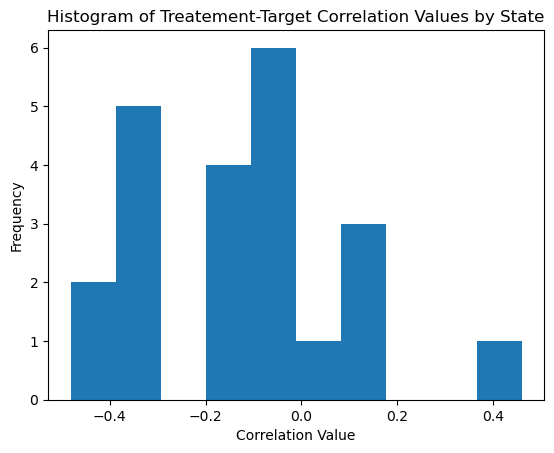

In [28]:
# visualize treatment - outcome correlations state by state
state_vals = df['state'].unique()
corr_vals = []
for curr_val in state_vals:
  curr_df = df[df['state'] == curr_val]
  corr_vals.append(curr_df['Price'].corr(curr_df['CONSUMPTION']))

plt.hist(corr_vals, bins=10)
plt.xlabel('Correlation Value')
plt.ylabel('Frequency')
plt.title('Histogram of Treatement-Target Correlation Values by State')
plt.show()

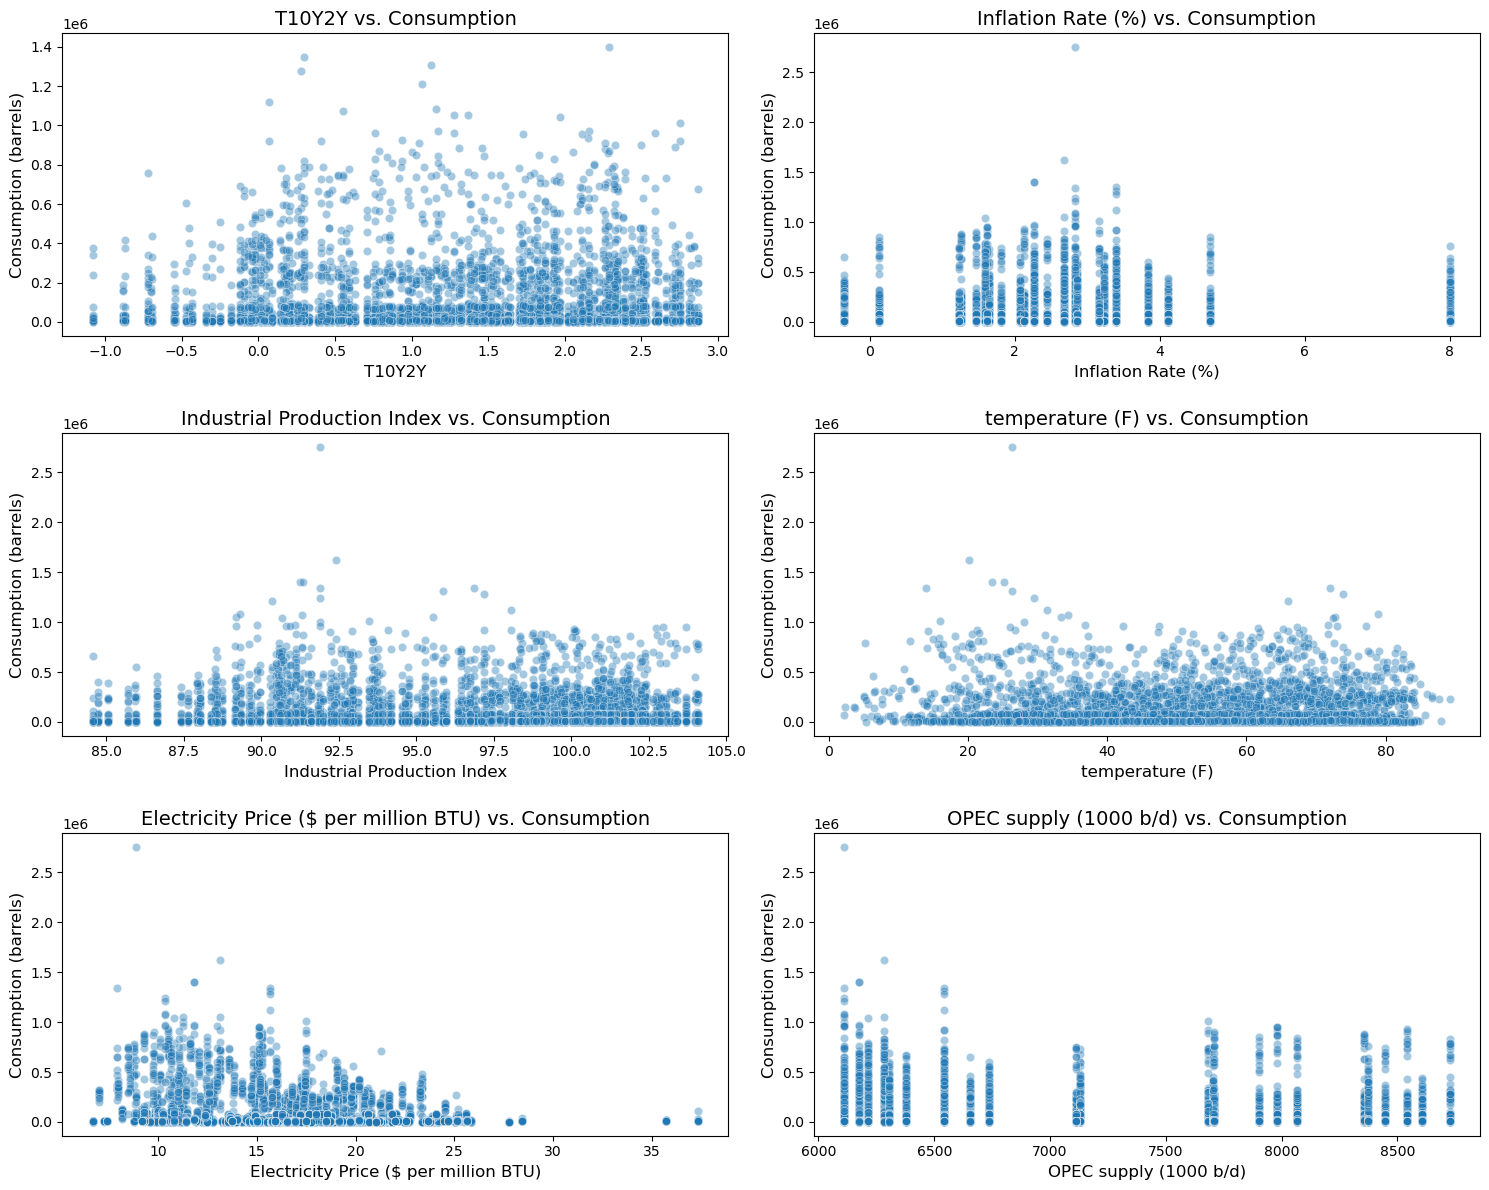

In [29]:
# visualize confounder - outcome relationships
target = 'CONSUMPTION'
exclude_features = ['Period', 'Year', 'Month', 'CONSUMPTION', 'state', 'State_Code']
features = [col for col in df.columns if col not in exclude_features]
features = features[-6:]

nrows, ncols = 3, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 12))
axes = axes.flatten()

num_plots = len(features)

for i in range(num_plots):
    feature = features[i]
    ax = axes[i]

    sns.scatterplot(x=df[feature], y=df[target], alpha=0.4, ax=ax)

    ax.set_title(f'{feature} vs. Consumption', fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Consumption (barrels)', fontsize=12)

for j in range(num_plots, nrows * ncols):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

STEP 3: perform modeling

In [30]:
# one hot encode state column
df = pd.get_dummies(df, columns=['state'], dtype=int)
df.head()

,State_Code,Period,Price,Year,Month,TYPE OF PRODUCER,ENERGY SOURCE (UNITS),CONSUMPTION,T10Y2Y,Inflation Rate (%),...,state_ND,state_NE,state_NM,state_OH,state_OK,state_PA,state_SD,state_TX,state_UT,state_WV
0,F001242__3,2001-01-01,28.02,2001,1,Total Electric Power Industry,Petroleum (Barrels),1005652,NaN,2.826171,...,0,0,0,0,0,1,0,0,0,0
1,F001242__3,2001-02-01,28.52,2001,2,Total Electric Power Industry,Petroleum (Barrels),196117,0.55,2.826171,...,0,0,0,0,0,1,0,0,0,0
2,F001242__3,2001-03-01,26.20,2001,3,Total Electric Power Industry,Petroleum (Barrels),478840,0.46,2.826171,...,0,0,0,0,0,1,0,0,0,0
3,F001242__3,2001-04-01,26.31,2001,4,Total Electric Power Industry,Petroleum (Barrels),960097,0.76,2.826171,...,0,0,0,0,0,1,0,0,0,0
4,F001242__3,2001-05-01,27.43,2001,5,Total Electric Power Industry,Petroleum (Barrels),524322,1.07,2.826171,...,0,0,0,0,0,1,0,0,0,0


In [31]:
for col in df.columns:
  print(f"column: {col}, type: {type(df[col].iloc[0])}")

column: State_Code, type: <class 'str'>
column: Period, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
column: Price, type: <class 'numpy.float64'>
column: Year, type: <class 'numpy.int32'>
column: Month, type: <class 'numpy.int32'>
column: TYPE OF PRODUCER, type: <class 'str'>
column: ENERGY SOURCE              (UNITS), type: <class 'str'>
column: CONSUMPTION, type: <class 'numpy.int64'>
column: T10Y2Y, type: <class 'numpy.float64'>
column: Inflation Rate (%), type: <class 'numpy.float64'>
column: Industrial Production Index, type: <class 'numpy.float64'>
column: temperature (F), type: <class 'numpy.float64'>
column: Electricity Price ($ per million BTU), type: <class 'numpy.float64'>
column: OPEC supply (1000 b/d), type: <class 'numpy.int64'>
column: state_AL, type: <class 'numpy.int64'>
column: state_AR, type: <class 'numpy.int64'>
column: state_CA, type: <class 'numpy.int64'>
column: state_CO, type: <class 'numpy.int64'>
column: state_IL, type: <class 'numpy.int64'>
colum

In [32]:
# apply seasonality feature
model_df = df.copy()
model_df['time_idx'] = (model_df['Year'] - 2000) * 12 + (model_df['Month'] - 1)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['Month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['Month'] / 12)
model_df.rename(columns={'ENERGY SOURCE              (UNITS)': 'ENERGY SOURCE (UNITS)'}, inplace=True)

# Set to ordered format
model_df['Period'] = pd.to_datetime(model_df['Period'])

model_df.drop(columns=['State_Code', 'TYPE OF PRODUCER', 'ENERGY SOURCE (UNITS)'], inplace=True)
print(model_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5947 entries, 0 to 5946
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Period                                 5947 non-null   datetime64[ns]
 1   Price                                  5947 non-null   float64       
 2   Year                                   5947 non-null   int32         
 3   Month                                  5947 non-null   int32         
 4   CONSUMPTION                            5947 non-null   Int64         
 5   T10Y2Y                                 5302 non-null   float64       
 6   Inflation Rate (%)                     5947 non-null   float64       
 7   Industrial Production Index            5947 non-null   float64       
 8   temperature (F)                        5947 non-null   float64       
 9   Electricity Price ($ per million BTU)  5947 non-null   float64 

In [33]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [36]:
# remove NaN values from dataset
model_df = model_df.dropna(inplace=True)

In [65]:
random_state=42
treatment = 'Price'
outcome = 'CONSUMPTION'

ate_df = model_df.copy()

treatment_med = ate_df['Price'].median()
T = np.where(ate_df['Price'] >= treatment_med, 1, 0).astype(np.int32)
ate_df.drop(columns=['Period', 'Year', 'Month'], errors='ignore', inplace=True)
features = [col for col in ate_df.columns if col not in ['CONSUMPTION', 'Price']]
X_confounders = ate_df[features]
X_array = X_confounders.values.astype(float) 
X_confounders_sm = sm.add_constant(X_array, prepend=True)
T_array = T.astype(float)

# Run the Logit model
logit_model = sm.Logit(T_array, X_confounders_sm)
logit_results = logit_model.fit(disp=0)

# Calculate propensity scores
propensity_scores = logit_results.predict(X_confounders_sm)
ate_df['propensity_score'] = propensity_scores
ate_df['T'] = T

# Perform Trimming on Extreme Propensity Values 
lower, upper = 0.025, 0.975
mask = (
    (ate_df['propensity_score'] > lower) &
    (ate_df['propensity_score'] < upper)
)
ate_trim = ate_df.loc[mask].copy()

Y = ate_trim[outcome].values
T_trim = ate_trim['T'].values
e = ate_trim['propensity_score'].values
N = len(ate_trim)

# Horvitz–Thompson IPW ATE formula: Sum[ (T*Y/e) - ((1-T)*Y/(1-e)) ] / N
ate_ht = (1 / N) * np.sum(
    (T_trim * Y / e) - ((1 - T_trim) * Y / (1 - e))
)
print(f"Horvitz–Thompson IPW ATE (HT): {ate_ht:.4f}")

Horvitz–Thompson IPW ATE (HT): -6915.6903
